# Processing LMHLD

In [32]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import random
import shutil

In [33]:
LMHLD_ROOT = "./dataset/LMHLD/Comparison_dataset_same_patch_size"
OUTPUT_ROOT = "./dataset/LMHLD_processed"

PATCH_SIZE = 128
STRIDE = 128

os.makedirs(f"{OUTPUT_ROOT}/landslide", exist_ok=True)
os.makedirs(f"{OUTPUT_ROOT}/non-landslide", exist_ok=True)

In [34]:
def to_uint8(img):
    img = img.astype(np.float32)
    img -= img.min()
    img /= (img.max() + 1e-6)
    img *= 255.0
    return img.astype(np.uint8)

In [35]:
def extract_patches_np(img, mask, patch_size=128, stride=128):
    """
    img:  (H, W, 3)
    mask: (H, W) binary {0,1}
    returns: list of (img_patch, mask_patch)
    """
    H, W, _ = img.shape
    patches = []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            ip = img[y:y+patch_size, x:x+patch_size, :]
            mp = mask[y:y+patch_size, x:x+patch_size]
            patches.append((ip, mp))

    return patches

In [36]:
def label_patch(mask_patch, threshold=0.05):
    """
    mask_patch: numpy array (H, W) with values {0,1}
    threshold: fraction of landslide pixels required
    """
    total_pixels = mask_patch.size
    landslide_pixels = np.count_nonzero(mask_patch > 0)

    ratio = landslide_pixels / total_pixels
    return 1 if ratio >= threshold else 0

In [37]:
def process_lmhld_split(images, masks, split_name):
    """
    images: (N, C, H, W)
    masks:  (N, 1, H, W)
    """
    count_pos, count_neg = 0, 0

    for idx in tqdm(range(len(images)), desc=f"LMHLD {split_name}"):
        img = images[idx][:3]          # (3, H, W)
        mask = masks[idx][0]           # (H, W)

        # (H, W, 3)
        img = np.transpose(img, (1, 2, 0))
        img = to_uint8(img)
        mask = (mask > 0).astype(np.uint8)

        patches = extract_patches_np(
            img, mask,
            patch_size=PATCH_SIZE,
            stride=STRIDE
        )

        for p_idx, (ip, mp) in enumerate(patches):
            cls = label_patch(mp, threshold=0.05)
            fname = f"{split_name}_{idx}_{p_idx}.png"

            if cls == 1:
                out = f"{OUTPUT_ROOT}/landslide/{fname}"
                count_pos += 1
            else:
                out = f"{OUTPUT_ROOT}/non-landslide/{fname}"
                count_neg += 1

            Image.fromarray(ip).save(out)

    return count_pos, count_neg

In [38]:
# splits = ["train", "val", "test"]

# total_pos, total_neg = 0, 0

# for s in splits:
#     images = np.load(f"{LMHLD_ROOT}/{s}_images.npy")
#     labels = np.load(f"{LMHLD_ROOT}/{s}_labels.npy")

#     pos, neg = process_lmhld_split(images, labels, s)
#     total_pos += pos
#     total_neg += neg

# print("\n===== LMHLD Conversion Summary =====")
# print("Landslide patches:", total_pos)
# print("Non-landslide patches:", total_neg)


# Processing CAS

In [ ]:
import os

zip_files = []
for root, dirs, files in os.walk('./dataset/cas-landslide-dataset'):
    for file in files:
        if file.endswith('.zip'):
            zip_files.append(os.path.join(root, file))

print("Found .zip files:")
for f in zip_files:
    print(f)

In [ ]:
import zipfile
import os

for zip_file_path in zip_files:
    # Extract the filename without the path and without the .zip extension
    base_name = os.path.basename(zip_file_path)
    dir_name = os.path.splitext(base_name)[0]

    # Create the full extraction path within DATASET_DIR
    extract_path = os.path.join('./dataset/cas_processed', dir_name)

    # Create the directory if it doesn't exist
    os.makedirs(extract_path, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is a bad zip file. Skipping extraction.")
    except Exception as e:
        print(f"Error extracting '{zip_file_path}': {e}")

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import shutil

In [ ]:
INPUT_ROOT = "./dataset/cas-landslide-dataset"
OUTPUT_ROOT = "./dataset/cas_processed"

PATCH_SIZE = 256
STRIDE = 256

In [ ]:
def create_folders():
    """Create only the two class directories under OUTPUT_ROOT.
    For k‑fold cross‑validation we keep all patches together; no train/val/test split.
    """
    for cls in ["landslide", "non-landslide"]:
        os.makedirs(os.path.join(OUTPUT_ROOT, cls), exist_ok=True)

def extract_patches(img, patch_size=256, stride=256):
    H, W = img.size[1], img.size[0]
    patches = []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = img.crop((x, y, x + patch_size, y + patch_size))
            patches.append(patch)

    return patches

def label_patch(mask_patch, threshold=0.03):
    """
    mask_patch: numpy array (H, W), values can be {0,1} or {0,255}
    threshold: fraction of landslide pixels required
    """
    # ensure numpy array
    if not isinstance(mask_patch, np.ndarray):
        mask_patch = np.array(mask_patch)

    # binarize mask safely
    landslide_mask = mask_patch > 0

    landslide_pixels = np.count_nonzero(landslide_mask)
    total_pixels = mask_patch.size

    ratio = landslide_pixels / total_pixels
    return 1 if ratio >= threshold else 0


In [ ]:
def process_single_image(img_path, label_path, prefix):
    """Extract patches from a single image and save them directly into the
    class folders under OUTPUT_ROOT. Returns counts of saved landslide and
    non‑landslide patches.
    """
    img = Image.open(img_path).convert("RGB")

    if not os.path.exists(label_path):
        print(f"[warning] Label file not found for {img_path}, expected {label_path}. Skipping.")
        return 0, 0

    mask = Image.open(label_path).convert("L")

    img_patches = extract_patches(img, PATCH_SIZE, STRIDE)
    mask_patches = extract_patches(mask, PATCH_SIZE, STRIDE)

    pos_count = 0
    neg_count = 0

    for i, (ip, mp) in enumerate(zip(img_patches, mask_patches)):
        cls = label_patch(mp, threshold=0.05)
        fname = f"{os.path.splitext(prefix)[0]}_{i}.jpg"
        if cls == 1:
            outp = os.path.join(OUTPUT_ROOT, "landslide", fname)
            ip.save(outp)
            pos_count += 1
        else:
            outp = os.path.join(OUTPUT_ROOT, "non-landslide", fname)
            ip.save(outp)
            neg_count += 1

    return pos_count, neg_count

In [ ]:
random.seed(42)
create_folders()

# Accumulators for total patches per class (no split distinction)
total_accum = {"landslide": 0, "non-landslide": 0}

for region in os.listdir(INPUT_ROOT):
    region_path = os.path.join(INPUT_ROOT, region)
    if not os.path.isdir(region_path):
        continue

    img_dir = os.path.join(region_path, "img")
    lbl_dir = os.path.join(region_path, "label")

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        continue

    for filename in tqdm(os.listdir(img_dir), desc=f"[Processing] {region}"):
        if not filename.lower().endswith(".tif"):
            continue

        img_path = os.path.join(img_dir, filename)
        label_path = os.path.join(lbl_dir, filename)

        if not os.path.exists(label_path):
            continue
        pos_c, neg_c = process_single_image(img_path, label_path, filename)
        total_accum['landslide'] += pos_c
        total_accum['non-landslide'] += neg_c

# No further splitting – patches are already saved into class folders.
print("\n===== Patch Extraction Summary (pre‑balance) =====")
print("Total landslide patches:", total_accum['landslide'])
print("Total non‑landslide patches:", total_accum['non-landslide'])

def balance_classes():
    land_dir = os.path.join(OUTPUT_ROOT, "landslide")
    non_dir = os.path.join(OUTPUT_ROOT, "non-landslide")
    land_files = [f for f in os.listdir(land_dir) if f.lower().endswith('.jpg')]
    non_files = [f for f in os.listdir(non_dir) if f.lower().endswith('.jpg')]
    cnt_land = len(land_files)
    cnt_non = len(non_files)
    if cnt_land == cnt_non:
        print("Classes already balanced.")
        return cnt_land, cnt_non
    # Determine target count (the larger of the two)
    target = max(cnt_land, cnt_non)
    # Choose which class to upsample
    if cnt_land < target:
        src_dir, src_files, src_cnt = land_dir, land_files, cnt_land
        cls_name = "landslide"
    else:
        src_dir, src_files, src_cnt = non_dir, non_files, cnt_non
        cls_name = "non-landslide"
    # Number of additional samples needed
    needed = target - src_cnt
    print(f"Balancing class '{cls_name}': need {needed} additional patches (target {target}).")
    for i in range(needed):
        # Randomly pick an existing file and copy it with a new name
        src_file = random.choice(src_files)
        base, ext = os.path.splitext(src_file)
        new_name = f"{base}_dup{i}{ext}"
        shutil.copy2(os.path.join(src_dir, src_file), os.path.join(src_dir, new_name))
    # Return final counts
    final_land = len([f for f in os.listdir(land_dir) if f.lower().endswith('.jpg')])
    final_non = len([f for f in os.listdir(non_dir) if f.lower().endswith('.jpg')])
    return final_land, final_non

# final_land, final_non = balance_classes()
# print("\n===== Patch Extraction Summary (post‑balance) =====")
# print("Final landslide patches:", final_land)
# print("Final non‑landslide patches:", final_non)

# Main clustering

In [39]:
import os
import shutil
from tqdm import tqdm
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import torch
import torch.nn as nn
from torchvision import models, transforms

In [40]:
DATASETS = [
    "./dataset/cas_processed",
    "./dataset/Bijie-landslide-dataset",
    "./dataset/LMHLD_processed"
]

TEMP_LANDSLIDE = "./temp/landslide"
TEMP_NON_LANDSLIDE = "./temp/non_landslide"

In [41]:
os.makedirs(TEMP_LANDSLIDE, exist_ok=True)
os.makedirs(TEMP_NON_LANDSLIDE, exist_ok=True)

In [42]:
def copy_images_from_dataset(DATASETS):
    """
    Copies images from datasets (handles both Type 1 and Type 2 dataset structures).
    Images are copied to TEMP_LANDSLIDE and TEMP_NON_LANDSLIDE based on their labels.

    :param DATASETS: List of dataset directories to process.
    """
    for ds in DATASETS:
        for lbl in ["landslide", "non-landslide"]:
            src = os.path.join(ds, lbl)
            if not os.path.exists(src):
                continue

            # Type 1 Dataset: Check if images are directly in the folder
            if any(f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif')) for f in os.listdir(src)):
                for f in os.listdir(src):
                    if f.lower().endswith((".jpg", ".png", ".jpeg")):
                        dest = TEMP_LANDSLIDE if lbl == "landslide" else TEMP_NON_LANDSLIDE
                        shutil.copy(os.path.join(src, f), os.path.join(dest, f))

            # Type 2 Dataset: Check subfolders for images
            else:
                for subfolder in os.listdir(src):
                    subfolder_path = os.path.join(src, subfolder)
                    if os.path.isdir(subfolder_path):
                        # Check if subfolder contains images
                        image_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]
                        
                        if image_files and subfolder == "image":  # If images exist in the subfolder
                            for img_file in image_files:
                                img_path = os.path.join(subfolder_path, img_file)
                                dest = TEMP_LANDSLIDE if lbl == "landslide" else TEMP_NON_LANDSLIDE
                                shutil.copy(img_path, os.path.join(dest, img_file))

In [43]:
copy_images_from_dataset(DATASETS)

In [44]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.efficientnet_b3(pretrained=False)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

model.load_state_dict(torch.load('./models/efficientnet_b3_best.pth', map_location="cpu"))
# remove last layer
model = nn.Sequential(*list(model.children())[:-1])
model.eval()
model = model.to(device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

d:\Individual_Project\Landslide Prediction\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Individual_Project\Landslide Prediction\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [45]:
def delete_temp_directories():
    if os.path.exists(TEMP_LANDSLIDE):
        shutil.rmtree(TEMP_LANDSLIDE)
    if os.path.exists(TEMP_NON_LANDSLIDE):
        shutil.rmtree(TEMP_NON_LANDSLIDE)

def load_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0)

In [46]:
features = []
paths = []

for f in tqdm(os.listdir(TEMP_LANDSLIDE)):
    p = os.path.join(TEMP_LANDSLIDE, f)
    img = load_image(p).to(device)
    with torch.no_grad():
        feat = model(img).cpu().numpy().reshape(-1)
    features.append(feat)
    paths.append(p)

features = np.array(features)

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(features)

100%|██████████| 86525/86525 [1:06:23<00:00, 21.72it/s]


d:\Individual_Project\Landslide Prediction\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\Individual_Project\Landslide Prediction\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


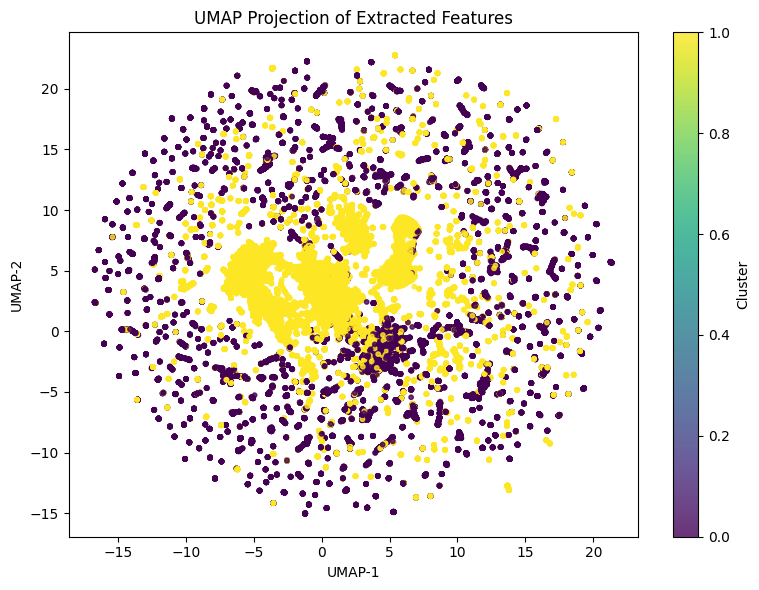

<Figure size 640x480 with 0 Axes>

In [47]:
import umap
import matplotlib.pyplot as plt

# UMAP projection
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

features_2d = reducer.fit_transform(features)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    features_2d[:,0],
    features_2d[:,1],
    c=cluster_labels,
    cmap="viridis",
    s=10,
    alpha=0.8
)

plt.title("UMAP Projection of Extracted Features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()

plt.show()

plt.savefig(
    "umap_feature_visualization.png",
    dpi=300,
    bbox_inches="tight"
)


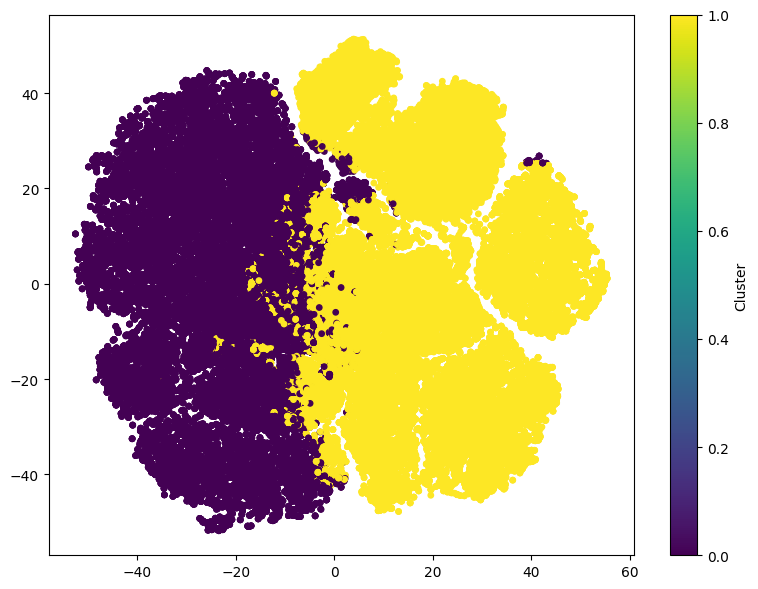

In [48]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Optional: PCA first (recommended if features >512 dims)
pca = PCA(n_components=50, random_state=42)
features_reduced = pca.fit_transform(features)

# t-SNE projection
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    # n_iter=2000,
    random_state=42
)

features_2d = tsne.fit_transform(features_reduced)

# Plot clusters
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    features_2d[:,0],
    features_2d[:,1],
    c=cluster_labels,
    cmap="viridis",
    s=15
)

# plt.title("Feature Embedding Visualization")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig(
    "landslide_feature_space.png",
    dpi=600,
    bbox_inches="tight",
    transparent=False
)
plt.show()

In [49]:
plt.savefig(
    "feature_visualization.png",
    # dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

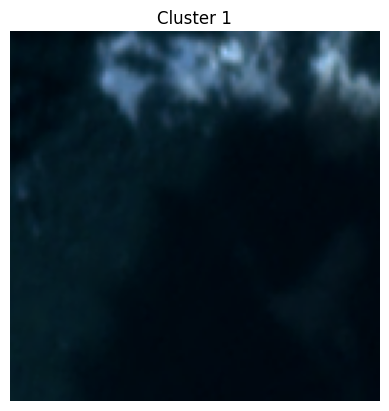

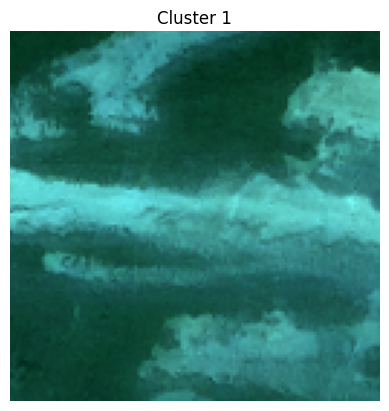

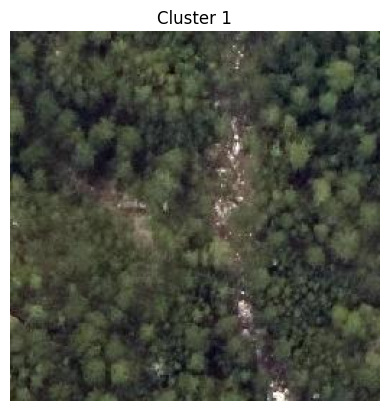

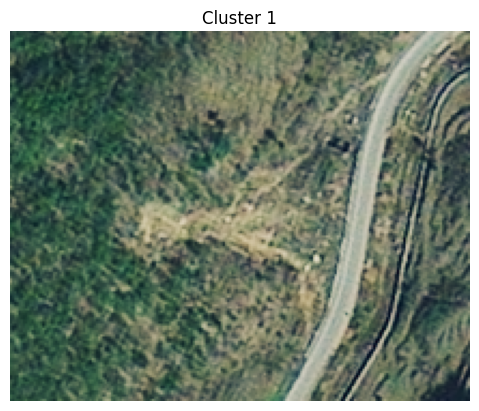

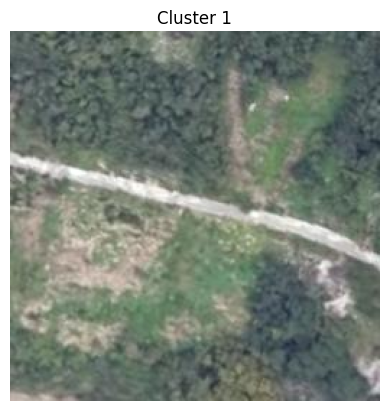

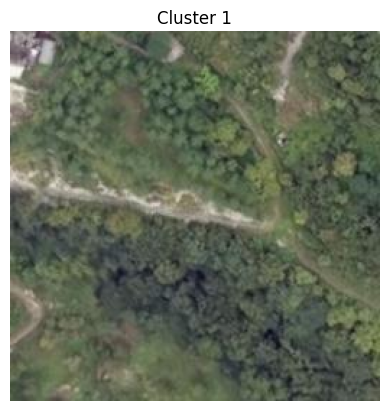

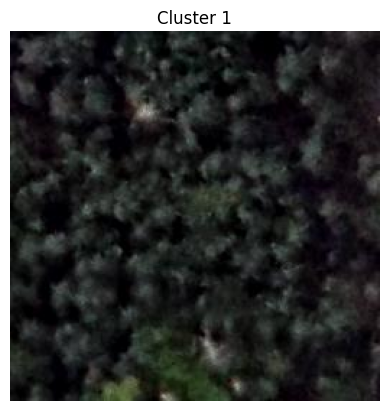

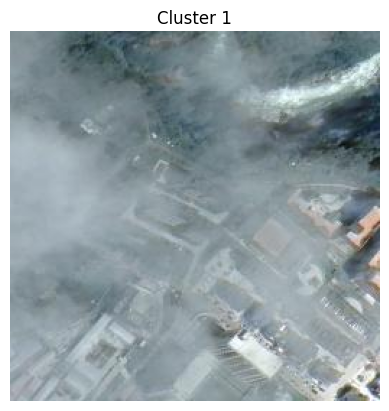

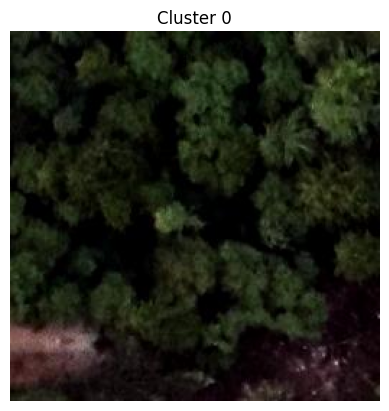

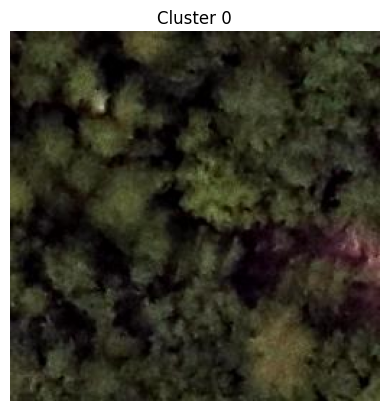

In [50]:
for i in range(10):
    idx = np.random.randint(len(paths))
    img = plt.imread(paths[idx])

    plt.figure()
    plt.imshow(img)
    plt.title(f"Cluster {cluster_labels[idx]}")
    plt.axis("off")

In [ ]:
# OUTPUT = "./dataset/bijie"
OUTPUT = "./dataset/final_dataset"
# OUTPUT = "./dataset/final_dataset_balanced"
# OUTPUT = "./dataset/final_dataset_gray"
os.makedirs(f"{OUTPUT}/non_landslide", exist_ok=True)
os.makedirs(f"{OUTPUT}/low_risk", exist_ok=True)
os.makedirs(f"{OUTPUT}/high_risk", exist_ok=True)

In [52]:
for f in os.listdir(TEMP_NON_LANDSLIDE):
    shutil.copy(os.path.join(TEMP_NON_LANDSLIDE, f), f"{OUTPUT}/non_landslide/{f}")

for p, lbl in zip(paths, cluster_labels):
    fname = os.path.basename(p)
    if lbl == 0:
        dest = f"{OUTPUT}/low_risk/{fname}"
    else:
        dest = f"{OUTPUT}/high_risk/{fname}"
    
    shutil.copy(p, dest)

In [53]:
print(f"Source folder size: {len(os.listdir(TEMP_LANDSLIDE)) + len(os.listdir(TEMP_NON_LANDSLIDE))} files")
print(f"Destination folder size: {len(os.listdir(f"{OUTPUT}/non_landslide")) + len(os.listdir(f"{OUTPUT}/high_risk")) + len(os.listdir(f"{OUTPUT}/low_risk"))} files")

Source folder size: 104342 files
Destination folder size: 104342 files


In [54]:
# delete_temp_directories()

In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# SOURCE_DIR = "./dataset/bijie"
SOURCE_DIR = "./dataset/final_dataset"
# SOURCE_DIR = "./dataset/final_dataset_gray"
# DEST_DIR = "./dataset/bijie_split"
DEST_DIR = "./dataset/final_dataset"
# DEST_DIR = "./dataset/final_dataset_gray_split"

TRAIN_RATIO = 0.7
SEED = 42

random.seed(SEED)

classes = ["non_landslide", "low_risk", "high_risk"]

# Create destination directories
for split in ["train", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

def split_class(class_name):
    src_dir = os.path.join(SOURCE_DIR, class_name)
    images = [f for f in os.listdir(src_dir)
              if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif"))]

    random.shuffle(images)

    split_idx = int(len(images) * TRAIN_RATIO)
    train_imgs = images[:split_idx]
    test_imgs = images[split_idx:]

    for img in tqdm(train_imgs, desc=f"Train {class_name}"):
        shutil.copy(
            os.path.join(src_dir, img),
            os.path.join(DEST_DIR, "train", class_name, img)
        )

    for img in tqdm(test_imgs, desc=f"Test {class_name}"):
        shutil.copy(
            os.path.join(src_dir, img),
            os.path.join(DEST_DIR, "test", class_name, img)
        )

# Run split for each class
for cls in classes:
    split_class(cls)


Test high_risk: 100%|██████████| 5346/5346 [00:08<00:00, 656.53it/s]


## Creating NPY

In [ ]:
import os

def count_images(base_dir):
    total = 0
    for cls in ["non_landslide", "low_risk", "high_risk"]:
        cls_dir = os.path.join(base_dir, cls)
        total += len(os.listdir(cls_dir))
    return total

# TRAIN_DIR = "./dataset/bijie_split/train"
TRAIN_DIR = "./dataset/final_dataset_split/train"
# TRAIN_DIR = "./dataset/final_dataset_gray_split/train"
# TEST_DIR = "./dataset/bijie_split/test"
TEST_DIR = "./dataset/final_dataset_split/test"
# TEST_DIR = "./dataset/final_dataset_gray_split/test"

N_TRAIN = count_images(TRAIN_DIR)
N_TEST = count_images(TEST_DIR)

print("Train:", N_TRAIN)
print("Test:", N_TEST)

Train: 55065
Test: 38825


In [58]:
import numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

CLASS_MAP = {
    "non_landslide": 0,
    "low_risk": 1,
    "high_risk": 2
}

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    # transforms.Grayscale()
])

def write_memmap(base_dir, X_path, y_path, n_samples):
    X_mm = np.memmap(
        X_path,
        dtype="float16",
        mode="w+",
        shape=(n_samples, 3, 224, 224)
    )

    y_mm = np.memmap(
        y_path,
        dtype="int64",
        mode="w+",
        shape=(n_samples,)
    )

    idx = 0

    for cls, label in CLASS_MAP.items():
        cls_dir = os.path.join(base_dir, cls)

        for img_name in tqdm(os.listdir(cls_dir), desc=f"Writing {cls}"):
            img_path = os.path.join(cls_dir, img_name)
            img = Image.open(img_path).convert("RGB")
            img = transform(img).half().numpy()

            X_mm[idx] = img
            y_mm[idx] = label
            idx += 1

    X_mm.flush()
    y_mm.flush()

    print(f"Saved {idx} samples → {X_path}")

In [ ]:
# OUTPUT = "./dataset/bijie_dat"
# OUTPUT = "./dataset/final_dataset_gray_dat"
OUTPUT = "./dataset/final_dataset_dat"
os.makedirs(OUTPUT, exist_ok=True)

write_memmap(
    TRAIN_DIR,
    f"{OUTPUT}/X_train.dat",
    f"{OUTPUT}/y_train.dat",
    N_TRAIN
)

write_memmap(
    TEST_DIR,
    f"{OUTPUT}/X_test.dat",
    f"{OUTPUT}/y_test.dat",
    N_TEST
)


Writing non_landslide:   0%|          | 0/12471 [00:00<?, ?it/s]

Writing high_risk: 100%|██████████| 21826/21826 [01:23<00:00, 261.21it/s]


Saved 55065 samples → ./dataset/final_dataset_balanced_dat/X_train.dat


Writing high_risk: 100%|██████████| 18514/18514 [01:11<00:00, 259.06it/s]


Saved 38825 samples → ./dataset/final_dataset_balanced_dat/X_test.dat


In [ ]:
np.save("./dataset/final_dataset_dat/meta_train.npy", {
    "shape": (N_TRAIN, 3, 224, 224),
    "dtype": "float16",
    "class_map": CLASS_MAP
})


In [ ]:
np.save("./dataset/final_dataset_dat/meta_test.npy", {
    "shape": (N_TEST, 3, 224, 224),
    "dtype": "float16",
    "class_map": CLASS_MAP
})
